<img src="../../Fink_PrimaryLogo_WEB.jpg" width=400 />

# Fink case study: extragalactic candidates with LSST

## Goal

This notebook illustrates how to use the Fink API to explore extragalactic transient candidates from the LSST/Rubin alert stream. We focus on two Fink-defined tags:

- **`extragalactic_lt20mag_candidate`**: bright extragalactic transient candidates with magnitude < 20.
- **`sn_near_galaxy_candidate`**: supernova candidates spatially coincident with a known galaxy.

For each tag, we show how to query the API, inspect the data, and leverage Fink's science modules outputs.

## What is behind?

This notebook uses:
- **Fink tags**: candidate lists built nightly by Fink from quality cuts, cross-matches, and ML scores. See https://doc.lsst.fink-broker.org/science/classification/
- **Fink's object API** to retrieve full multi-band photometry for individual `diaObject`s.

API reference: https://api.lsst.fink-portal.org  
Field definitions: https://doc.lsst.fink-broker.org/services/api/definitions/

## Environment set up

Standard libraries only — all available in Colab.

In [91]:
import requests
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})

APIURL = 'https://api.lsst.fink-portal.org'

## Field names and schema

Fink/LSST alert fields are prefixed by their origin (see https://doc.lsst.fink-broker.org/services/api/definitions/):
- `r:` — original LSST fields
- `f:` — Fink science module outputs (ML scores, cross-matches, ...)
- `v:` — values computed at query runtime
- `b:` — cutout data

You can programmatically retrieve the full schema for any endpoint:

In [121]:
# Retrieve the schema for the /api/v1/sources endpoint
r_schema = requests.get(
    '{}/api/v1/schema'.format(APIURL),
    params={'endpoint': '/api/v1/sources'}
)
schema = r_schema.json()

# Print the Fink science module outputs (v: fields) relevant to cross-matching
fink_fields = schema.get('Fink science module outputs (f:)', {})
xm_fields = {k: v for k, v in fink_fields.items() if k.startswith('xm_')}

print('Fink cross-matching fields (f:):')
for name, meta in xm_fields.items():
    print(f"  f:{name}  —  {meta['doc'][:90]}")

Fink cross-matching fields (f:):
  f:xm_gaiadr3_DR3Name  —  Unique source designation of closest source from Gaia catalog; if exists within 1 arcsec.
  f:xm_gaiadr3_Plx  —  Absolute stellar parallax (in milli-arcsecond) of the closest source from Gaia catalog; if
  f:xm_gaiadr3_VarFlag  —  Photometric variability flag from Gaia DR3. 1 if the source is variable, 0 otherwise.
  f:xm_gaiadr3_e_Plx  —  Standard error of the stellar parallax (in milli-arcsecond) of the closest source from Gai
  f:xm_gcvs_type  —  Object type of the closest source from GCVS catalog; if exists within 1 arcsec.
  f:xm_legacydr8_e_zphot  —  Uncertainty on zphot from Legacy Surveys DR8 South Photometric Redshifts catalog - standar
  f:xm_legacydr8_fqual  —  Photo-z reliability flag from Legacy Surveys DR8 South Photometric Redshifts catalog. =1 f
  f:xm_legacydr8_pstar  —  Star likelihood based on colours from GMM star-QSO classification (Legacy Surveys DR8 Sout
  f:xm_legacydr8_zphot  —  Photo-z estimate from L

# 1. Bright extragalactic candidates

The tag `extragalactic_lt20mag_candidate` is assigned by Fink to alerts that pass extragalactic selection criteria and have a measured PSF magnitude below 20. This is a useful starting point to build a bright, actionable follow-up list.

The full list of available Fink tags is at https://api.lsst.fink-portal.org/api/v1/tags.

### <font color='blue'>API query:</font> <font color='orange'>latest alerts</font> tagged as bright extragalactic candidates

In [94]:
r = requests.post(
    '{}/api/v1/tags'.format(APIURL),
    json={
        'tag': 'extragalactic_lt20mag_candidate',
        'n': '10',
    }
)

pdf = pd.read_json(io.BytesIO(r.content))
print(f'Retrieved {len(pdf)} alerts')

Retrieved 10 alerts


The table contains per-alert information including the latest photometry point and Fink-added values. The full schema is at https://doc.lsst.fink-broker.org/services/api/definitions/ or programmatically via `/api/v1/schema`.

In [95]:
pdf.head()

,f:clf_cats_class,f:clf_cats_score,f:clf_earlySNIa_score,f:clf_elephant_kstest_science,f:clf_elephant_kstest_template,f:clf_snnSnVsOthers_score,f:fink_broker_version,f:fink_science_version,f:lsst_schema_version,f:xm_gaiadr3_DR3Name,...,r:trailLengthErr,r:trailNdata,r:trailRa,r:trailRaErr,r:trail_flag_edge,r:visit,r:x,r:xErr,r:y,r:yErr
0,12,0.999954,-1.000000,NaN,NaN,0.198571,5.0rc0,8.49.0,lsst.v10_0,Gaia DR3 3833530685621513728,...,0.084054,0,149.928637,NaN,False,2026060400135,1126.8638,0.031527,1239.3448,0.028275
1,11,0.999992,-1.000000,NaN,NaN,0.819196,5.0rc0,8.49.0,lsst.v10_0,nan,...,0.111874,0,151.163540,NaN,False,2026060400135,2691.6174,0.055161,2517.2760,0.048951
2,11,0.999297,-1.000000,NaN,NaN,0.033899,5.0rc0,8.49.0,lsst.v10_0,Fail,...,0.226865,0,149.463352,NaN,False,2026060300112,3418.9355,0.176035,2660.6720,0.136641
3,11,0.999996,0.675439,NaN,NaN,0.867563,5.0rc0,8.49.0,lsst.v10_0,Fail,...,0.162789,0,151.163537,NaN,False,2026060300112,4025.1600,0.122306,1174.8976,0.099664
4,11,0.961704,-1.000000,NaN,NaN,0.142086,5.0rc0,8.49.0,lsst.v10_0,Fail,...,0.179412,0,150.114333,NaN,False,2026060300112,3392.4763,0.131214,485.7441,0.110056


### <font color='blue'>Tip:</font> <font color='orange'>select only the columns you need</font>

By default the API returns all ~130 fields. If you only need a subset — for example to build a target list or cross-match — pass the `columns` parameter to reduce transfer size and speed up the query. Column names follow the `prefix:field` convention described in the schema section above.

Useful columns for a lightweight object list:

| Column | Description |
|---|---|
| `r:diaObjectId` | Unique object identifier |
| `r:ra`, `r:dec` | Sky position |

In [96]:
# Request only the columns needed — here just the object ID
r_slim = requests.post(
    '{}/api/v1/tags'.format(APIURL),
    json={
        'tag': 'extragalactic_lt20mag_candidate',
        'n': '10',
        'columns': 'r:diaObjectId,r:ra,r:dec',
    }
)

pdf_slim = pd.read_json(io.BytesIO(r_slim.content))
print(f'Columns returned: {list(pdf_slim.columns)}')
pdf_slim.head()

Columns returned: ['r:dec', 'r:diaObjectId', 'r:ra']


,r:dec,r:diaObjectId,r:ra
0,2.997570,170028500588167170,150.114315
1,2.997535,170028500588167170,150.114301
2,2.507443,170411112000913487,151.163543
3,2.997573,170028500588167170,150.114332
4,2.507433,170411112000913487,151.163541


### <font color='blue'>Inspect:</font> <font color='orange'>alerts per diaObject</font>

Multiple alerts can correspond to the same astrophysical object (`r:diaObjectId`). Grouping by `r:diaObjectId` shows how many times each object has been observed within this sample.

In [97]:
alerts_per_object = (
    pdf.groupby('r:diaObjectId')
    .size()
    .reset_index(name='n_alerts')
    .sort_values('n_alerts', ascending=False)
)
print(alerts_per_object.to_string(index=False))

     r:diaObjectId  n_alerts
170028500588167170         4
170411112000913487         4
170028510474666056         1
314003014107006318         1


Objects with multiple alerts have been detected on several separate visits. We pick the one with the most alerts for the light-curve inspection below.

## 1.1 Plot light-curve

We select the `diaObjectId` with the most alerts and query all its photometry via the `/api/v1/sources` endpoint (see the `lsst/photometry` tutorial for a full walkthrough).

### <font color='blue'>API query:</font> <font color='orange'>photometry</font> for one bright extragalactic candidate

In [98]:
selected_id = alerts_per_object['r:diaObjectId'].iloc[0]
print(f'Selected diaObjectId: {selected_id}')

columns = [
    'r:midpointMjdTai',
    'r:psfFlux',
    'r:psfFluxErr',
    'r:band',
]

r = requests.post(
    '{}/api/v1/sources'.format(APIURL),
    json={
        'diaObjectId': str(selected_id),
        'columns': ','.join(columns),
        'output-format': 'json',
    }
)

pdf_obj = pd.read_json(io.BytesIO(r.content))
print(f'Retrieved {len(pdf_obj)} photometry points')

Selected diaObjectId: 170028500588167170
Retrieved 429 photometry points


### <font color='blue'>Inspect:</font> first rows of the photometry table

In [99]:
pdf_obj.head()

,r:band,r:midpointMjdTai,r:psfFlux,r:psfFluxErr
0,z,61196.044028,63313.832,1063.96040
1,z,61196.043532,63456.457,1159.86120
2,y,61196.041480,52922.996,2751.31980
3,y,61196.040962,60658.527,2924.17200
4,r,61196.038951,39914.180,490.75644


### <font color='blue'>Plot:</font> <font color='orange'>multi-band light-curve</font>

We use a colour and marker scheme consistent with the LSST filter set and plot the difference-image PSF flux as a function of time.

In [100]:
UNIQUE_BANDS = ['u', 'g', 'r', 'i', 'z', 'y']
MARKERS = {'u': 'o', 'g': '<', 'r': '>', 'i': 's', 'z': '*', 'y': 'p'}
COLORS  = {
    'u': '#15284f', 'g': '#626d84', 'r': '#afb2b9',
    'i': '#dbbeb2', 'z': '#e89070', 'y': '#f5622e'
}

def plot_lightcurve(pdf_phot, title=''):
    """Plot multi-band difference-image PSF flux light-curve.

    Parameters
    ----------
    pdf_phot : pd.DataFrame
        DataFrame with columns r:midpointMjdTai, r:psfFlux, r:psfFluxErr, r:band.
    title : str
        Plot title (e.g. diaObjectId).
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    for band in UNIQUE_BANDS:
        mask = pdf_phot['r:band'] == band
        if mask.sum() == 0:
            continue
        ax.errorbar(
            pdf_phot.loc[mask, 'r:midpointMjdTai'],
            pdf_phot.loc[mask, 'r:psfFlux'],
            pdf_phot.loc[mask, 'r:psfFluxErr'],
            color=COLORS[band],
            marker=MARKERS[band],
            label=f'{band} band',
            ls='',
        )

    ax.axhline(0, ls='--', color='grey', lw=0.8)
    ax.set_xlabel('Time (MJD)')
    ax.set_ylabel('PSF Flux (nJy)')
    ax.set_title(title or str(selected_id))
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

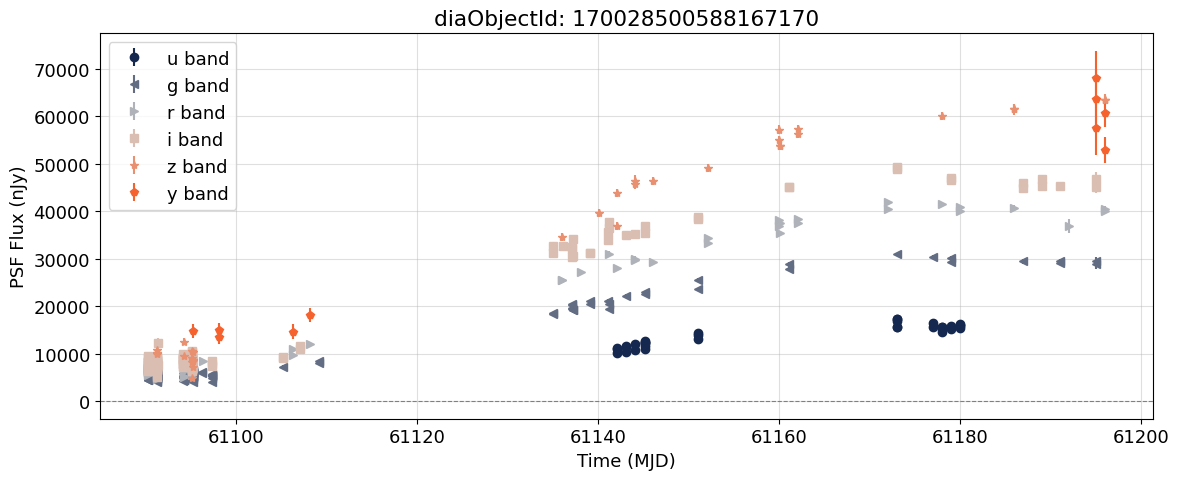

In [101]:
plot_lightcurve(pdf_obj, title=f'diaObjectId: {selected_id}')

# 2. SN candidates near a galaxy

The tag `sn_near_galaxy_candidate` selects alerts that are spatially consistent with a known galaxy. This tag is particularly useful to build a sample of hosted transients.

We query the latest alerts for this tag.

### <font color='blue'>API query:</font> <font color='orange'>latest alerts</font> tagged as SN candidates near a galaxy

In [102]:
GALAXY_COLS = ','.join([
    'r:diaObjectId', 'r:ra', 'r:dec',
    'r:psfFlux', 'r:psfFluxErr', 'r:band',
    'f:xm_mangrove_ang_dist', 'f:xm_mangrove_lum_dist',
    'f:xm_mangrove_HyperLEDA_name', 'f:xm_mangrove_2MASS_name',
    'f:xm_legacydr8_zphot', 'f:xm_legacydr8_e_zphot', 'f:xm_legacydr8_fqual',
    'f:xm_tns_redshift',
])

r = requests.post(
    '{}/api/v1/tags'.format(APIURL),
    json={
        'tag': 'sn_near_galaxy_candidate',
        'n': '100',
        'columns': GALAXY_COLS,
        'output-format': 'json',
    }
)

pdf_sn = pd.read_json(io.BytesIO(r.content))
print(f'Retrieved {len(pdf_sn)} alerts, {pdf_sn["r:diaObjectId"].nunique()} unique objects')
pdf_sn.head(3)

Retrieved 100 alerts, 78 unique objects


,f:xm_legacydr8_e_zphot,f:xm_legacydr8_fqual,f:xm_legacydr8_zphot,r:band,r:dec,r:diaObjectId,r:psfFlux,r:psfFluxErr,r:ra,f:xm_tns_redshift,f:xm_mangrove_2MASS_name,f:xm_mangrove_HyperLEDA_name,f:xm_mangrove_ang_dist,f:xm_mangrove_lum_dist
0,0.278,1,1.241,g,2.947896,313875416771199127,2638.1125,345.46980,148.873207,NaN,nan,NaN,NaN,NaN
1,2.235,0,0.705,g,2.998947,313875416773296195,2426.3890,368.19778,149.221265,NaN,nan,NaN,NaN,NaN
2,0.346,1,1.236,g,1.865042,313875416786927752,5028.1655,385.28064,148.857682,NaN,nan,NaN,NaN,NaN


## 2.1 Host galaxy cross-match analysis

Fink cross-matches every alert against two galaxy catalogues at query time (`f:` prefix):

| Field | Catalogue | Description |
|---|---|---|
| `f:xm_mangrove_ang_dist` | Mangrove | Angular distance to nearest galaxy within 1 arcmin (arcsec) |
| `f:xm_mangrove_lum_dist` | Mangrove | Luminosity distance of the matched galaxy (Mpc) |
| `f:xm_mangrove_HyperLEDA_name` | Mangrove / HyperLEDA | HyperLEDA identifier of the host |
| `f:xm_legacydr8_zphot` | Legacy Surveys DR8 | Photo-*z* of the nearest galaxy in the field |
| `f:xm_legacydr8_e_zphot` | Legacy Surveys DR8 | Photo-*z* uncertainty |
| `f:xm_legacydr8_fqual` | Legacy Surveys DR8 | Quality flag (1 = reliable photo-*z*) |
| `f:xm_tns_redshift` | TNS | Spectroscopic redshift, if already reported |

We use these to characterise the host-galaxy population and assess how bright the transients are relative to their distance.

### <font color='blue'>Inspect:</font> <font color='orange'>host-galaxy match statistics</font>

In [111]:
def _is_matched(col,pdf):
    """True where the cross-match succeeded (not NaN, not 'Fail', not 'nan')."""
    s = pdf[col].astype(str)
    return ~s.isin(['nan', 'Fail', 'None', '']) & pdf[col].notna()

n_tot = len(pdf_sn)
n_mangrove = _is_matched('f:xm_mangrove_HyperLEDA_name', pdf_sn).sum()
n_2mass    = _is_matched('f:xm_mangrove_2MASS_name', pdf_sn).sum()
n_legacy   = _is_matched('f:xm_legacydr8_zphot', pdf_sn).sum()
n_tns      = _is_matched('f:xm_tns_redshift', pdf_sn).sum()

print(f'Total alerts              : {n_tot}')
print(f'Mangrove/HyperLEDA match  : {n_mangrove:3d}  ({100*n_mangrove/n_tot:.0f}%)')
print(f'Mangrove/2MASS match      : {n_2mass:3d}  ({100*n_2mass/n_tot:.0f}%)')
print(f'Legacy DR8 photo-z        : {n_legacy:3d}  ({100*n_legacy/n_tot:.0f}%)')
print(f'TNS spectroscopic z       : {n_tns:3d}  ({100*n_tns/n_tot:.0f}%)')

# One row per unique object (keep first alert per object)
pdf_sn_unique = pdf_sn.groupby("r:diaObjectId", as_index=False).first()

n_tot      = len(pdf_sn_unique)
n_mangrove = _is_matched('f:xm_mangrove_HyperLEDA_name', pdf_sn_unique).sum()
n_2mass    = _is_matched('f:xm_mangrove_2MASS_name',     pdf_sn_unique).sum()
n_legacy   = _is_matched('f:xm_legacydr8_zphot',         pdf_sn_unique).sum()
n_tns      = _is_matched('f:xm_tns_redshift',            pdf_sn_unique).sum()

print("")
print(f'Total unique objects       : {n_tot}')
print(f'Mangrove/HyperLEDA match   : {n_mangrove:3d}  ({100*n_mangrove/n_tot:.0f}%)')
print(f'Mangrove/2MASS match       : {n_2mass:3d}  ({100*n_2mass/n_tot:.0f}%)')
print(f'Legacy DR8 photo-z         : {n_legacy:3d}  ({100*n_legacy/n_tot:.0f}%)')
print(f'TNS spectroscopic z        : {n_tns:3d}  ({100*n_tns/n_tot:.0f}%)')

Total alerts              : 100
Mangrove/HyperLEDA match  :   1  (1%)
Mangrove/2MASS match      :   0  (0%)
Legacy DR8 photo-z        : 100  (100%)
TNS spectroscopic z       :   4  (4%)

Total unique objects       : 78
Mangrove/HyperLEDA match   :   1  (1%)
Mangrove/2MASS match       :   0  (0%)
Legacy DR8 photo-z         :  78  (100%)
TNS spectroscopic z        :   1  (1%)


### <font color='blue'>Plot:</font> <font color='orange'>angular separation from host and photo-*z* distribution</font>

A small angular offset from the galaxy nucleus is expected for a hosted SN. Very large separations (> 30 arcsec) may indicate a chance coincidence or a misidentification.

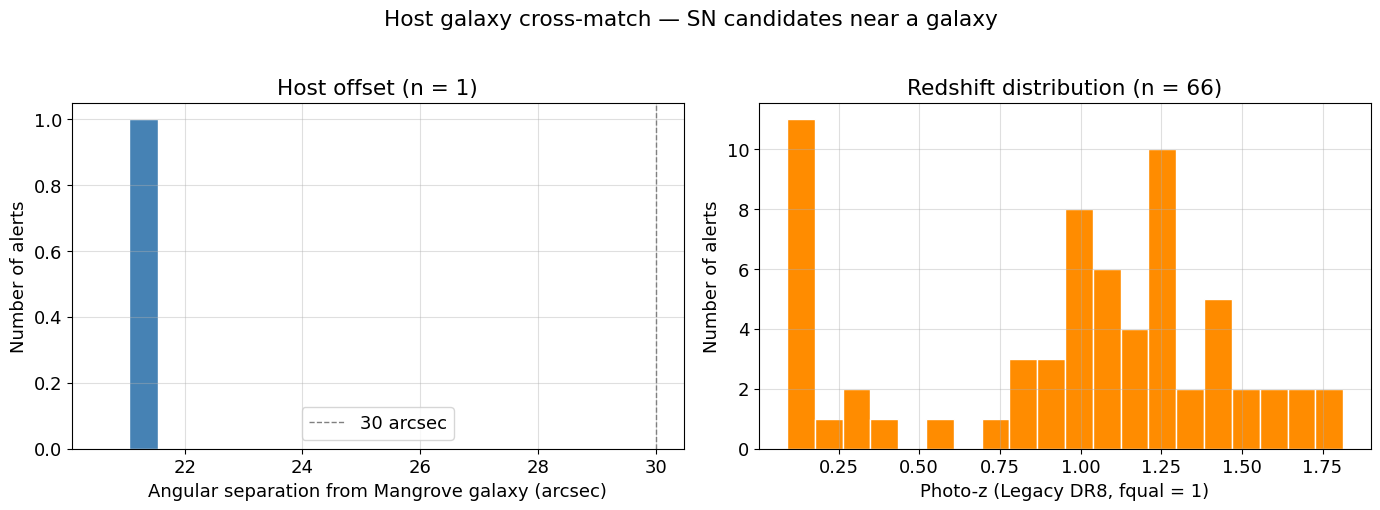

In [112]:
# Clean numeric columns
ang  = pd.to_numeric(pdf_sn['f:xm_mangrove_ang_dist'], errors='coerce')
zphot = pd.to_numeric(pdf_sn['f:xm_legacydr8_zphot'],  errors='coerce')
fqual = pd.to_numeric(pdf_sn['f:xm_legacydr8_fqual'],  errors='coerce')

ang_ok   = ang.dropna()
z_ok     = zphot[fqual == 1].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: angular separation
axes[0].hist(ang_ok, bins=2, color='steelblue', edgecolor='white')
axes[0].axvline(30, ls='--', color='grey', lw=1, label='30 arcsec')
axes[0].set_xlabel('Angular separation from Mangrove galaxy (arcsec)')
axes[0].set_ylabel('Number of alerts')
axes[0].set_title(f'Host offset (n = {len(ang_ok)})')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Right: photo-z distribution (reliable only)
axes[1].hist(z_ok, bins=20, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Photo-z (Legacy DR8, fqual = 1)')
axes[1].set_ylabel('Number of alerts')
axes[1].set_title(f'Redshift distribution (n = {len(z_ok)})')
axes[1].grid(alpha=0.4)

plt.suptitle('Host galaxy cross-match — SN candidates near a galaxy', y=1.02)
plt.tight_layout()
plt.show()

### <font color='blue'>Plot:</font> <font color='orange'>transient PSF flux vs. host distance</font>

We compare the PSF flux of each alert to the distance of its host:

- **Left**: PSF flux max distribution per band — how bright these transients appear on sky at maximum light measurement.
- **Right**: PSF flux max vs. photo-*z*.

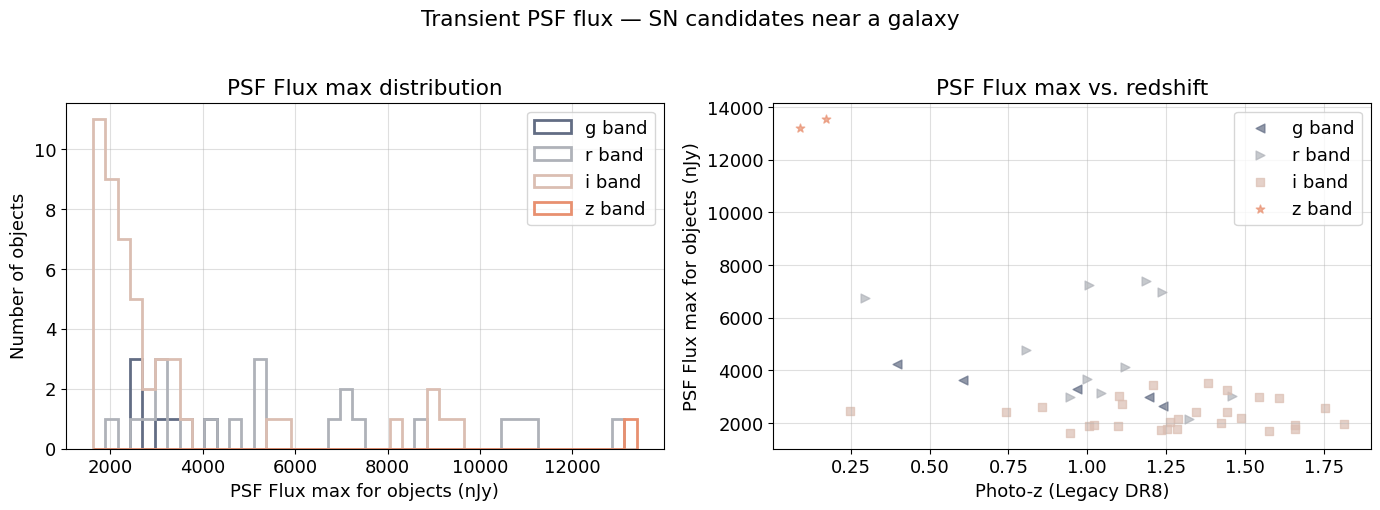

In [120]:
pdf_sn_grouped = pdf_sn.groupby('r:diaObjectId').agg('max').reset_index()
flux = pd.to_numeric(pdf_sn_grouped['r:psfFlux'], errors='coerce')
band = pdf_sn_grouped['r:band']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PSF flux per band
mybins = np.arange(pdf_sn_grouped['r:psfFlux'].min(), pdf_sn_grouped['r:psfFlux'].max(), pdf_sn_grouped['r:psfFlux'].min()-pdf_sn_grouped['r:psfFlux'].max()/10)
for b in UNIQUE_BANDS:
    mask = (band == b) & flux.notna()
    if mask.sum() == 0:
        continue
    axes[0].hist(
        flux[mask], bins=mybins, histtype='step',
        lw=2, color=COLORS[b], label=f'{b} band',
    )
axes[0].set_xlabel('PSF Flux max for objects (nJy)')
axes[0].set_ylabel('Number of objects')
axes[0].set_title('PSF Flux max distribution')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Right: PSF flux vs. photo-z, coloured by band
zphot = pd.to_numeric(pdf_sn_grouped['f:xm_legacydr8_zphot'], errors='coerce')
fqual = pd.to_numeric(pdf_sn_grouped['f:xm_legacydr8_fqual'], errors='coerce')

for b in UNIQUE_BANDS:
    mask = (band == b) & flux.notna() & zphot.notna() & (fqual == 1)
    if mask.sum() == 0:
        continue
    axes[1].scatter(
        zphot[mask], flux[mask],
        color=COLORS[b], marker=MARKERS[b],
        s=40, alpha=0.7, label=f'{b} band',
    )
axes[1].set_xlabel('Photo-z (Legacy DR8)')
axes[1].set_ylabel('PSF Flux max for objects (nJy)')
axes[1].set_title('PSF Flux max vs. redshift')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('Transient PSF flux — SN candidates near a galaxy', y=1.02)
plt.tight_layout()
plt.show()

# Summary

In this notebook we demonstrated how to work with Fink extragalactic candidate tags for LSST/Rubin:

- Queried the `/api/v1/schema` endpoint to inspect available field names and their origin prefix (`r:`, `f:`, ...).
- Queried the `extragalactic_lt20mag_candidate` tag to retrieve bright extragalactic alerts and grouped them by `r:diaObjectId`.
- Used the `columns` parameter to request only the fields needed, reducing transfer size.
- Fetched full multi-band photometry for a selected object via `/api/v1/sources` and plotted its difference-image light-curve.
- Queried the `sn_near_galaxy_candidate` tag with galaxy cross-match columns (`f:xm_mangrove_*`, `f:xm_legacydr8_*`, `f:xm_tns_redshift`).
- Computed host-galaxy match statistics: fraction of alerts with a Mangrove and/or Legacy DR8 counterpart.
- Plotted the angular separation from the Mangrove host galaxy and the photo-*z* distribution from Legacy DR8.
- Showed apparent magnitude distributions per band and apparent magnitude vs. redshift.
- Estimated indicative absolute magnitudes from Mangrove luminosity distances.

## An issue to report, or a question to ask: contact@fink-broker.org